# SDG&E Electric Grid Polyon to Lines

SDG&E electric grid data is in polygon format when downloaded. This is different from the electric grid data acquired from SCE and PG&E which is in line format. This notebook creates line data from the polygon data. 

In [1]:
# load necessary libraries
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box  # To create polygon bounding box
import glob
import os
import folium # for the interactive map
import pygeoops # to get the centerline of the polygons

# Connecting the Polygons

To riterate this analysis is relying on feeder line data. SDG&E holds feeder line data in polygons. We'll use `GeoPandas` `dissolve()` function to aggregate the polygons based on the `LINE_SEGMENT_NUMBER`. Geospatially, the load and generation capacity maps are the same but the values are different across the two layers. This analysis will be completed for both the load and generation capacity layers. 

### Find the unique combinations throughout the electricity grid
Find the unique combinations of `LINE_SEGMENT_NUMBER`, `CIRCUIT_NAME`, `SUBID`, `ICAWOF_UNIGENERATION`, `ICAWOF_UNILOAD`, `ICAWNOF_UNIGENERATION`, and `ICAWNOF_UNILOAD`.

In [2]:
# load SDGE generation capacity data
sdge_generation_capacity = gpd.read_file("../../../../capstone/electrigrid/data/utilities/sandiego_grid/ICA_MAP_PROD_GenerationCapacityGrids.geojson")

The unique values are down to the `LINE_SEGMENT_NUMBER` layer so we need to ensure that all of this data is maintained. Checking the number of unique values at each level acts as a confirmation that the information is being maintained. 

In [3]:
# check how many values there are of each different column
print(len(list(sdge_generation_capacity['LINE_SEGMENT_NUMBER'].unique())))
print(len(list(sdge_generation_capacity['CIRCUIT_NAME'].unique())))
print(len(list(sdge_generation_capacity['SUBID'].unique())))

144658
645
104


The following variables require further investigation to delineate what the differences between the rows means

In [4]:
print(sdge_generation_capacity['VOLTAGE'].unique())

print(sdge_generation_capacity['ICAWOF_UNILOAD_LC'].unique())
print(sdge_generation_capacity['ICAWOF_UNIGENERATION_LC'].unique())
print(sdge_generation_capacity['ICAWNOF_UNIGENERATION_LC'].unique())

[12]
['Load_Voltage' 'Load_Thermal']
['ICA_Operation_Flex' 'ICA_Voltage' 'ICA_Protection' 'ICA_Thermal'
 'ICA_Voltage_Delta']
['ICA_Voltage' 'ICA_Voltage_Delta' 'ICA_Thermal' 'ICA_Protection']


In [5]:
# view the dataframe
sdge_generation_capacity.head()

,OBJECTID,VOLTAGE,LINE_SEGMENT_NUMBER,ICAWOF_UNIGENERATION,ICAWOF_UNILOAD,ICAWOF_PVGENERATION,OHUG,CIRCUIT_NAME,LABELTEXT,ICAWNOF_UNIGENERATION,ICAWNOF_UNILOAD,ICAWNOF_PVGENERATION,LABELTEXT_ICA,RESTRICTED,SUBID,ICAWOF_UNIGENERATION_LC,ICAWOF_UNILOAD_LC,ICAWNOF_UNIGENERATION_LC,geometry
0,32500971,12,189790,0.0,2.1,0.2,OH,204,None,1.1,2.1,1.3,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"POLYGON ((-117.51529 33.39328, -117.51529 33.3..."
1,32500972,12,189790,0.0,2.1,0.2,OH,204,None,1.1,2.1,1.3,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"POLYGON ((-117.51529 33.39294, -117.51529 33.3..."
2,32500973,12,189790,0.0,2.1,0.2,OH,204,None,1.1,2.1,1.3,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"POLYGON ((-117.51611 33.39362, -117.51611 33.3..."
3,32500974,12,189790,0.0,2.1,0.2,OH,204,None,1.1,2.1,1.3,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"POLYGON ((-117.51611 33.39328, -117.51611 33.3..."
4,32500975,12,846583,0.0,3.0,0.2,OH,204,None,0.1,3.0,0.7,0,N,SAN MATEO,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"POLYGON ((-117.55531 33.37352, -117.55532 33.3..."


Our analysis is only concerned with a subsection of the variables. Aggregate the data to the level of interest. 

In [6]:
# create a list with the variables of interest
attributes = ['LINE_SEGMENT_NUMBER',
              'CIRCUIT_NAME', 
              'SUBID', 
              'ICAWOF_UNIGENERATION', 
              'ICAWOF_UNILOAD', 
              'ICAWNOF_UNIGENERATION', 
              'ICAWNOF_UNILOAD']

# aggregate the data down to the variable of interest
sdge_agg_lines = sdge_generation_capacity.dissolve(by = attributes, as_index=False)

# Utilize `pygeoops.centerline` to get centerlines

Calculate the centerlines with pygeoops.

**Note:** This takes just under ten minutes to run. 


In [7]:
sdge_agg_lines.geometry = pygeoops.centerline(sdge_agg_lines.geometry)

In [8]:
sdge_agg_lines.head()

,LINE_SEGMENT_NUMBER,CIRCUIT_NAME,SUBID,ICAWOF_UNIGENERATION,ICAWOF_UNILOAD,ICAWNOF_UNIGENERATION,ICAWNOF_UNILOAD,geometry,OBJECTID,VOLTAGE,ICAWOF_PVGENERATION,OHUG,LABELTEXT,ICAWNOF_PVGENERATION,LABELTEXT_ICA,RESTRICTED,ICAWOF_UNIGENERATION_LC,ICAWOF_UNILOAD_LC,ICAWNOF_UNIGENERATION_LC
0,1,221,SANTA YSABEL,0.0,0.2,0.0,0.2,"LINESTRING (-116.43681 32.97732, -116.43681 32...",32929650,12,0.1,OH,None,0.1,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage
1,21,211,WARNERS,0.0,0.0,0.0,0.0,"LINESTRING (-116.52521 33.22100, -116.52521 33...",32789112,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage
2,22,211,WARNERS,0.0,0.0,0.0,0.0,"LINESTRING (-116.52522 33.21894, -116.52522 33...",32783141,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage
3,24,211,WARNERS,0.0,0.0,0.0,0.0,"LINESTRING (-116.53426 33.21107, -116.53426 33...",32784298,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage
4,25,211,WARNERS,0.0,0.0,0.0,0.0,"LINESTRING (-116.53751 33.21427, -116.53730 33...",32784301,12,0.1,OH,None,0.2,0,N,ICA_Voltage,Load_Voltage,ICA_Voltage


Make sure that the granularity of the data is maintained. 

In [9]:
# check how many values there are of each different column
print(len(list(sdge_agg_lines['LINE_SEGMENT_NUMBER'].unique())))
print(len(list(sdge_agg_lines['CIRCUIT_NAME'].unique())))
print(len(list(sdge_agg_lines['SUBID'].unique())))

144658
645
104


## Plot the line segment data
Visualize the change from polygons to lines of the `LINE_SEGMENT_NUMBER`.

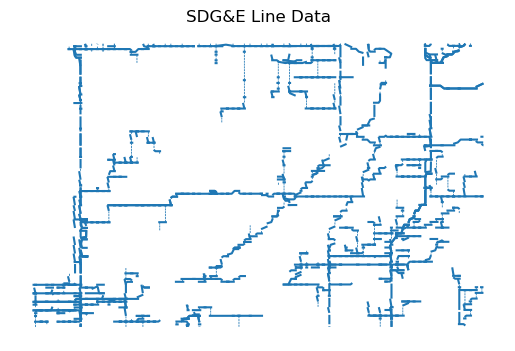

In [10]:
# make a bbox to get a closer look
sd_bbox = box(-117.136541,32.713699,-117.071653,32.747959)

# use the San Diego bbox to make better analyze the findings
sub_sdge_agg_lines = gpd.clip(sdge_agg_lines, sd_bbox)

# plot the subset of gen line data 
fig, ax = plt.subplots()

sub_sdge_agg_lines.plot(ax=ax)

ax.set_title('SDG&E Line Data')
ax.axis('off')

plt.show()

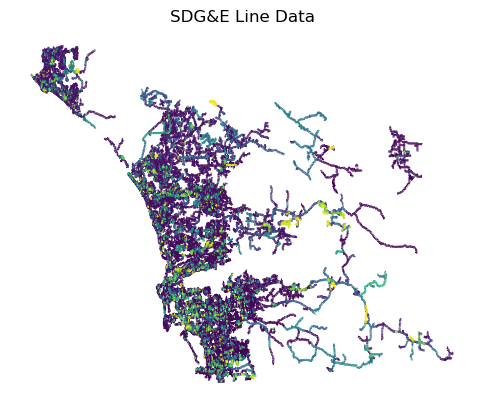

In [11]:
# plot the all of the generation line data
fig, ax = plt.subplots()

sdge_agg_lines.plot(ax=ax, 
                    column = 'LINE_SEGMENT_NUMBER')

ax.set_title('SDG&E Line Data')
ax.axis('off')

plt.show()

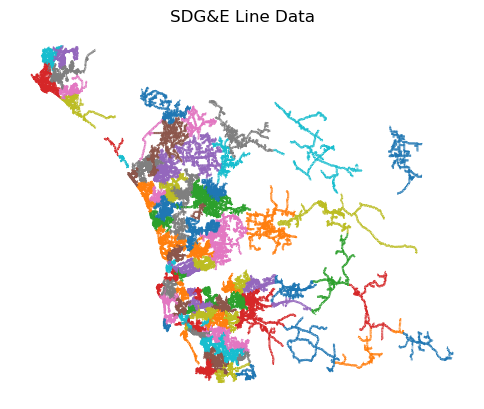

In [12]:
# plot the all of the generation line data
fig, ax = plt.subplots()

sdge_agg_lines.plot(ax=ax, 
                    column = 'SUBID')

ax.set_title('SDG&E Line Data')
ax.axis('off')

plt.show()

Save the centerlines for use in later analysis. The next code chunk saves it directly to the directory where the file is being run. It has been downloaded and added to the capstone data folder on workbench 2. It is commented out to avoid git issues from accidentally attempting to push large amounts of data.

In [ ]:
# # save the a geojson file of the lines from generation capacity
# output_shapefile_path = 'gen_cap_lines_sdge.geojson'

# sdge_agg_lines.to_file(output_shapefile_path)

In [14]:
# read in the file to make sure it worked
gen_line_sdge = gpd.read_file("../../../../capstone/electrigrid/data/utilities/sandiego_grid/gen_cap_lines_sdge.geojson")

# view the new data frame
gen_line_sdge.head()

,CIRCUIT_NAME,SUBID,ICAWOF_UNIGENERATION,ICAWOF_UNILOAD,ICAWNOF_UNIGENERATION,ICAWNOF_UNILOAD,OBJECTID,VOLTAGE,LINE_SEGMENT_NUMBER,ICAWOF_PVGENERATION,OHUG,LABELTEXT,ICAWNOF_PVGENERATION,LABELTEXT_ICA,RESTRICTED,ICAWOF_UNIGENERATION_LC,ICAWOF_UNILOAD_LC,ICAWNOF_UNIGENERATION_LC,geometry
0,1001,RANCHO SANTA FE,0.0,0.2,0.0,0.2,32504073,12,136796,0.1,OH,None,0.1,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"MULTILINESTRING ((-117.20041 33.07905, -117.19..."
1,1001,RANCHO SANTA FE,0.0,0.3,0.0,0.3,32504074,12,136855,0.1,OH,None,0.1,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"MULTILINESTRING ((-117.21182 33.07010, -117.21..."
2,1001,RANCHO SANTA FE,0.0,0.4,0.0,0.4,32760214,12,133569,0.1,UG,None,0.1,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"MULTILINESTRING ((-117.21004 33.06048, -117.21..."
3,1001,RANCHO SANTA FE,0.0,0.5,0.0,0.5,32756360,12,127942,0.1,UG,None,0.1,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"MULTILINESTRING ((-117.21829 33.04844, -117.21..."
4,1001,RANCHO SANTA FE,0.0,0.6,0.0,0.6,32760465,12,133915,0.1,UG,None,0.5,0,N,ICA_Operation_Flex,Load_Voltage,ICA_Voltage,"MULTILINESTRING ((-117.21423 33.05635, -117.21..."


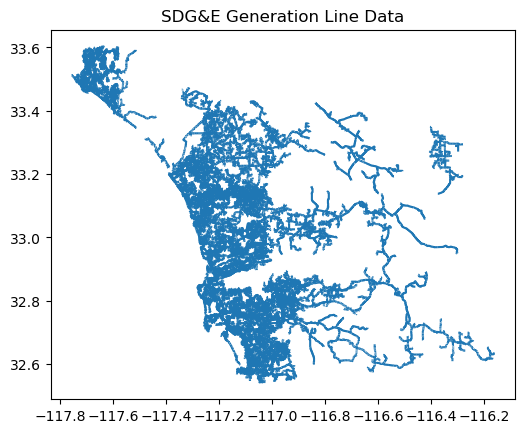

In [15]:
# plot the line data to ensure its all there
fig, ax = plt.subplots()
gen_line_sdge. plot (ax=ax)
ax. set_title('SDG&E Generation Line Data')
# ax.axis('off') 
plt. show()

# Explore the lines that are appearing on the map 

In [16]:
# make a bbox to get a closer look
line_bbox = box(-117.178863,32.604331,-116.837943,32.828195)

# use the line investigation bbox to better analyze the issue
line_invest = gpd.clip(gen_line_sdge, line_bbox)


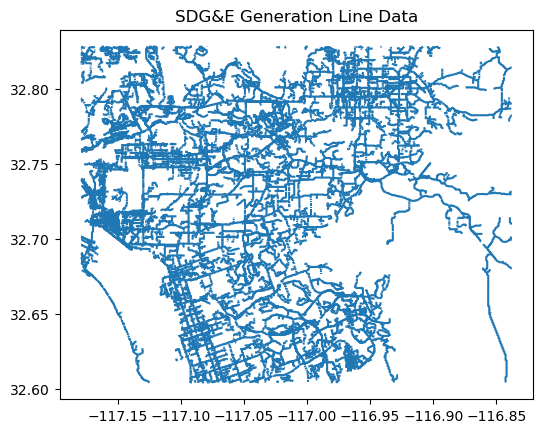

In [17]:
# plot the line data problem area
fig, ax = plt.subplots()
line_invest. plot (ax=ax)
ax. set_title('SDG&E Generation Line Data')
# ax.axis('off') 
plt. show()

Plot the original polygonas and the lines to see what's happening.

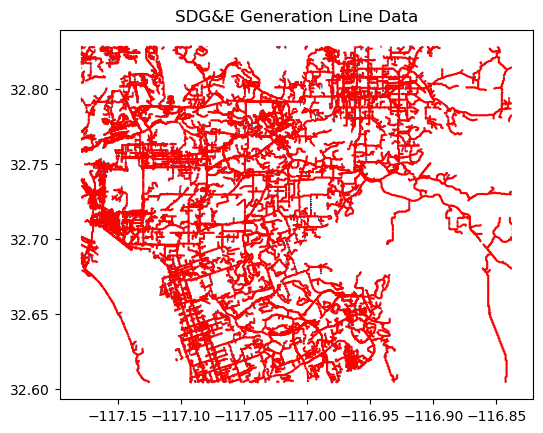

In [18]:
# make a bbox to get a closer look
line_bbox = box(-117.178863,32.604331,-116.837943,32.828195)

# use the line investigation bbox to better analyze the issue
line_invest = gpd.clip(gen_line_sdge, line_bbox)
polygon_invest = gpd.clip(sdge_generation_capacity, line_bbox)



# plot the line data problem area
fig, ax = plt.subplots()

line_invest. plot (ax=ax,
                   color = "red")
polygon_invest.plot(ax=ax)


ax. set_title('SDG&E Generation Line Data')
# ax.axis('off') 
plt. show()

# Replicate the above with the load hosting capacity

Save the centerlines for use in later analysis. The next code chunk saves load capacity lines directly to the directory where the file is being run. It has been downloaded and added to the capstone data folder on workbench 2. It is commented out to avoid git issues from accidentally attempting to push large amounts of data.

In [ ]:
# # load SDGE generation capacity data
# sdge_load_capacity = gpd.read_file("../../../../capstone/electrigrid/data/utilities/sandiego_grid/ICA_MAP_PROD_LoadCapacityGrids.geojson")

# # create a list of the variables of interest
# attributes = ['LINE_SEGMENT_NUMBER',
#               'CIRCUIT_NAME', 
#               'SUBID', 
#               'ICAWOF_UNIGENERATION', 
#               'ICAWOF_UNILOAD', 
#               'ICAWNOF_UNIGENERATION', 
#               'ICAWNOF_UNILOAD']

# # aggregate to the level of analysis of interest
# sdge_load_agg_lines = sdge_load_capacity.dissolve(by = attributes, as_index=False)


# # calculate the center lines for each of the polygons
# sdge_load_agg_lines.geometry = pygeoops.centerline(sdge_load_agg_lines.geometry)

# output_shapefile_path = 'load_cap_lines_sdge.geojson'

# sdge_load_agg_lines.to_file(output_shapefile_path)


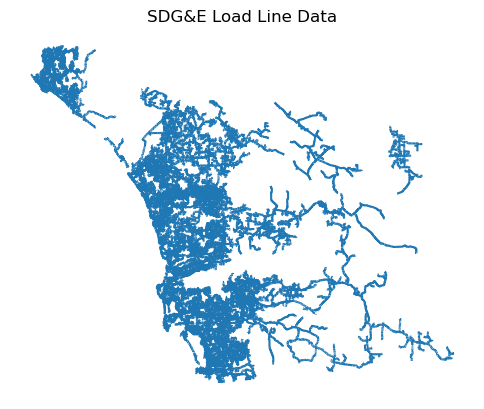

In [20]:
# read in the new file to make sure it worked
load_line_sdge = gpd.read_file("../../../../capstone/electrigrid/data/utilities/sandiego_grid/load_cap_lines_sdge.geojson")

# view the new data frame
load_line_sdge.head()

# plot the line data to ensure its all there
fig, ax = plt.subplots()
load_line_sdge. plot (ax=ax)
ax. set_title('SDG&E Load Line Data')
ax.axis('off') 
plt. show()

The lines through the different maps in the same place in both maps is perlexing. This will take some investigation. 